In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, log_loss
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import joblib


features = pd.read_csv("../data/customer_features.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")

In [52]:
# churn target
df["returned"] = (df["revenue_2018_2019"] > 0).astype(int)

In [53]:
X = df.drop(columns=["cust_id", "revenue_2018_2019", "returned"])
y = df["returned"]

In [54]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LightGBM

In [55]:
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lgb_param_grid = {
    "n_estimators": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "num_leaves": [32, 64, 128],
    "min_child_samples": [20, 30, 50],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

search_lgb = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight),
    param_distributions=lgb_param_grid,
    n_iter=20,                  # number of random combinations to try
    scoring="roc_auc",          # optimise for AUC
    cv=5,                       # 5-fold cross-validation
    random_state=42,      
    n_jobs=-1                   # Use all CPU Cores
)

search_lgb.fit(X_train, y_train)

print("Best params:", search_lgb.best_params_)
print("Best AUC:", search_lgb.best_score_)

lgb_model = search_lgb.best_estimator_
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 27284, number of negative: 47333
[LightGBM] [Info] Number of positive: 27285, number of negative: 47333
[LightGBM] [Info] Number of positive: 27285, number of negative: 47333[LightGBM] [Info] Number of positive: 27285, number of negative: 47332

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025683 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5511
[LightGBM] [Info] Number of data points in the train set: 74617, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.365654 -> initscore=-0.550907
[LightGBM] [Info] Start training from score -0.550907
[LightGBM] [Info] Number of positive: 27285, number of negative: 47333
[LightGBM] [Info] Number of positive: 27284, number of negative: 47333
[LightGBM] [Info] Number of positive: 27285, number of negative: 47332
[LightGBM] [Info

,boosting_type,'gbdt'
,num_leaves,32
,max_depth,-1
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [56]:
p_val_lgb = lgb_model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, p_val_lgb)
ll = log_loss(y_val, p_val_lgb)

print("AUC:", auc)
print("Log loss:", ll)

AUC: 0.720944041409552
Log loss: 0.6016667952851751


In [57]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
11,avg_size,1794
14,recency_days,1337
23,revenue_recency_ratio,996
22,frequency_recency_ratio,911
2,max_item_revenue,817
0,total_revenue,771
12,size_std,693
1,avg_item_revenue,567
24,discount_per_item,566
5,total_discount,525


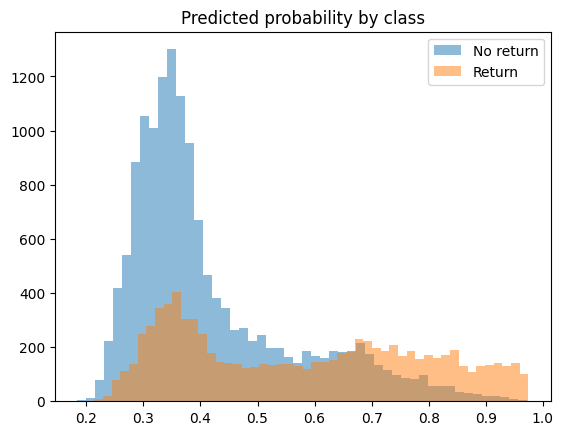

In [58]:
plt.hist(p_val_lgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_lgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# XGBoost

In [59]:
xgb_param_grid = {
    "n_estimators": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5]
}

search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric="logloss"),
    param_distributions=xgb_param_grid,
    n_iter=20,                  # number of random combinations to try
    scoring="roc_auc",          # optimise for AUC
    cv=5,                       # 5-fold cross-validation
    random_state=42,
    n_jobs=-1                   # Use all CPU Cores
)

search_xgb.fit(X_train, y_train)

print("Best params:", search_xgb.best_params_)
print("Best AUC:", search_xgb.best_score_)

xgb_model = search_xgb.best_estimator_

xgb_model.fit(X_train, y_train)

p_val_xgb = xgb_model.predict_proba(X_val)[:,1]

print("XGBoost AUC:", roc_auc_score(y_val, p_val_xgb))
print("XGBoost LogLoss:", log_loss(y_val, p_val_xgb))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:02:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:02:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:02:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:02:35] WARN

Best params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
Best AUC: 0.7214840103576476


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:08:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.7215506815787711
XGBoost LogLoss: 0.6019478231492809


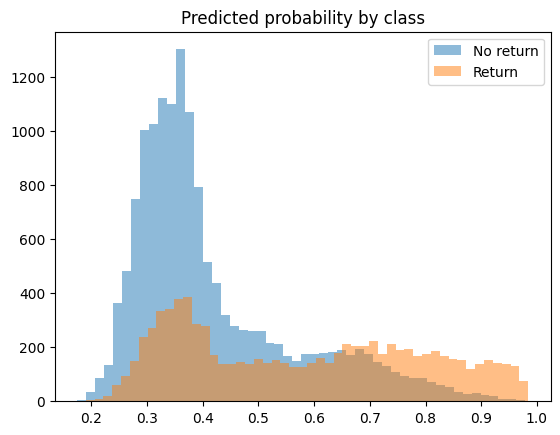

In [60]:
plt.hist(p_val_xgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_xgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# CatBoost

In [61]:
cat_param_grid = {
    "iterations": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bylevel": [0.7, 0.8, 0.9],
    "min_child_samples": [20, 30, 50]
}

search_cat = RandomizedSearchCV(
    CatBoostClassifier(random_state=42, scale_pos_weight=scale_pos_weight, loss_function="Logloss", verbose=False),
    param_distributions=cat_param_grid,
    n_iter=20,                  # number of random combinations to try
    scoring="roc_auc",          # optimise for AUC
    cv=5,                       # 5-fold cross-validation
    random_state=42,
    n_jobs=-1                   # Use all CPU Cores
)

search_cat.fit(X_train, y_train)

print("Best params:", search_cat.best_params_)
print("Best AUC:", search_cat.best_score_)

cat_model = search_cat.best_estimator_
cat_model.fit(X_train, y_train)

p_val_cat = cat_model.predict_proba(X_val)[:,1]

print("CatBoost AUC:", roc_auc_score(y_val, p_val_cat))
print("CatBoost LogLoss:", log_loss(y_val, p_val_cat))

Best params: {'subsample': 0.8, 'min_child_samples': 50, 'learning_rate': 0.01, 'iterations': 1200, 'depth': 8, 'colsample_bylevel': 0.9}
Best AUC: 0.7213295506947628
CatBoost AUC: 0.7215022840286247
CatBoost LogLoss: 0.6015478533303833


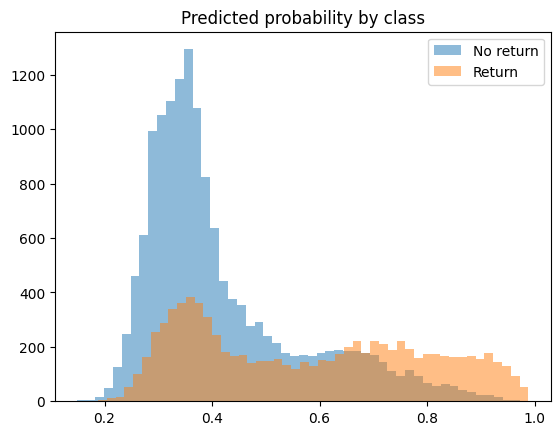

In [62]:
plt.hist(p_val_cat[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_cat[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# Comparison

In [63]:
results = {
    "LightGBM": roc_auc_score(y_val, p_val_lgb),
    "XGBoost": roc_auc_score(y_val, p_val_xgb),
    "CatBoost": roc_auc_score(y_val, p_val_cat)
}

results

{'LightGBM': 0.720944041409552,
 'XGBoost': 0.7215506815787711,
 'CatBoost': 0.7215022840286247}

# Save Models

In [64]:
import os
os.makedirs("../models", exist_ok=True)


In [65]:
feature_cols = X.columns.tolist()

joblib.dump(feature_cols, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [66]:
joblib.dump(lgb_model, "../models/churn_lgb_model.pkl")
joblib.dump(xgb_model, "../models/churn_xgb_model.pkl")
joblib.dump(cat_model, "../models/churn_cat_model.pkl")

['../models/churn_cat_model.pkl']